# Traditional evaluation pipeline

This notebook explores conduct traditional evaluation pipeline: train and evaluate on the same token networks. In particular, this notebook answer the following research questions:

I. How do traditional machine learning models such as Logistic Regression, Random Forest, Gradient Boosting (GBM), SVM and KNN perform in predicting whether the `close price` of a token increase/decrease in the next day (binary classification)? What is the importance of each feature contributing to the prediction?

II. How do traditional machine learning models such as Linear Regression, Ridge, Lasso, Random Forest (regression version), GBM and SVR perform in predicting `close price` of a token in the following day (regression)? What is the importance of each feature contributing to the prediction?

III. Can time-series model such as ARIMA performs better in regression task?

## 1. Set up

We first set up the environment for experiment. This step include

1. Import all dependencies
2. Declare global environment to config the experiment
3. Declare all support functions needed for the experiment

### 1. Import all dependencies

This experiment requires the following libraries to run
- tensorflow
- sklearn
- numpy
- pmdarima
- seaborn
- matplotlib

*If your virtual environment is missing any of these library, you need to run `pip install` to install missing libraries*

In [2]:
from src.data import Dataloader
import pandas as pd
import os
from src.utils import seed_everything
from tqdm import tqdm
from typing import Callable
from src.data import TimeSeriesDataset
from sklearn.metrics import roc_auc_score
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
import copy

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
import warnings

import pmdarima as pm
from typing import Tuple

import seaborn as sns
import matplotlib.pyplot as plt
from src.nn import SlidingWindowBinaryClassification, SlidingWindowRegression

import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers




### 1.2 Declare global environment to config the experiment

This section below will set up constant needed for experiment

**Important: To save time, we load the results (if they have been already generated by previous run). If you want to regenerate the results, please set `RE_RUN_EVERYTHING` to `False`**

In [3]:
# Clean data location
DATA_PATH = os.path.abspath('data/clean/')

# Path to where we cache the result
RESULT_PATH = os.path.abspath('data/results/')

# Train, validation and test split
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15  

# Columns that are used as features for training
ALL_FEAT_COLUMN = ['Close','High','Low', 'Open','Volume','sentiment_score_mean','sentiment_polarity_mean','sentiment_subjectivity_mean','news_count', 'log_return', 'vol_7d','vol_30d','ma_7','ma_30','ma_ratio']

# Columns that are used as features for training but do NOT need to normalize
ALREADY_NORMALIZE_FEAT = ['sentiment_score_mean','sentiment_polarity_mean','sentiment_subjectivity_mean','news_count','ma_ratio','log_return']

# Label for binary classification task
BINARY_LABEL_COLUMN = 'price_increase'

# Label for regression task
REGRESSION_LABEL_COLUMN = 'next_close'

# Window size for RNN, GRU and Sliding window baseline
WINDOW_SIZE = 7

# Number of tokens used in training to demonstrate scaling laws
LOG_SCALING = [2,4,8,16,32]

# For reproducibility, inital random seed
INIT_SEED = 720

# Force re-run. To save time, we load the results (if they have been already generated by previous run.
# If the results have not yet computed or `RE_RUN_EVERYTHING` is set to True, the following script re-generate everything
RE_RUN_EVERYTHING = False

seed_everything(INIT_SEED)

files = os.listdir(DATA_PATH)


### 1.3. Declare all support functions needed for the experiment

To conduct experiment, we define the following support functions

1. `normalize`: normalize continuous features for training

In [ ]:
def normalize(train_data: TimeSeriesDataset, valid_data: TimeSeriesDataset, test_data: TimeSeriesDataset, normalize_y = False, exclude_cols = []):
    r"""
    Normalize each feature in training, validation and testing data with max and min of the feature from training data.

    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `valid_data` (TimeSeriesDataset): data split for validation
    - `test_data` (TimeSeriesDataset): data split for testing
    - `normalize_y` (bool): whether to normalize input (True for regresison case and False for binary classification case)
    - `exclude_cols` (list): columns that don't need to normalize

    Return:
    - data splits for training, validation and testing with normalized features
    """
    n_cols = train_data.x.shape[1]
    include_cols = [i for i in range(n_cols) if i not in (exclude_cols or [])]

    max_values= np.max(train_data.x[:, include_cols], axis=0)
    min_values = np.min(train_data.x[:, include_cols], axis=0)

    denom = (max_values - min_values)
    denom[denom == 0] = 1  

    for data in [train_data, valid_data, test_data]:
        data.x[:, include_cols] = (data.x[:, include_cols] - min_values) / denom

    if normalize_y:
        max_y = np.max(train_data.y, axis=0)
        min_y = np.min(train_data.y, axis=0)
        for data in [train_data, valid_data, test_data]:
            data.y = (data.y - min_y) / (max_y - min_y)

    return train_data, valid_data, test_data

2. `binary_classfication_model_experiment`: Given each token dataset, run all baseline for binary classification task


In [5]:
def binary_classfication_model_experiment(train_data: TimeSeriesDataset,val_data: TimeSeriesDataset, test_data: TimeSeriesDataset):
    r"""
    Train and evaluate multiple binary classification baseline models on time series data.

    Each model is trained on the training split and evaluated on the test split using
    ROC-AUC score as the performance metric. C
    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `val_data` (TimeSeriesDataset): data split for validation
    - `test_data` (TimeSeriesDataset): data split for testing

    Return:
    - `results` (dict): dictionary mapping model name to its ROC-AUC score on the test split
    """
    train_x = np.concatenate([train_data.x,val_data.x])
    train_y = np.concatenate([train_data.y.squeeze(),val_data.y.squeeze()])
    test_x = test_data.x
    test_y = test_data.y.squeeze()

    models = {
        "Logistic Regression":     LogisticRegression(),
        "Random Forest":           RandomForestClassifier(),
        "Gradient Boosting (GBM)": GradientBoostingClassifier(),
        "SVM":                     SVC(probability=True),
        "KNN":                     KNeighborsClassifier(),
    }
    results = {}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for name, model in models.items():
            model.fit(train_x, train_y)
            preds = model.predict_proba(test_x)[:, 1]
            auc = roc_auc_score(test_y, preds)
            results[name] = auc

    return results

3. `regression_classfication_model_experiment`: Given each token dataset, run all baseline for regression classification task


In [6]:
def regression_classfication_model_experiment(train_data: TimeSeriesDataset,val_data: TimeSeriesDataset, test_data: TimeSeriesDataset):
    r"""
    Train and evaluate multiple regression baseline models on time series data.

    Each model is trained on the training split and evaluated on the test split using
    Root Mean Squared Error (RMSE) as the performance metric.

    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `val_data` (TimeSeriesDataset): data split for validation
    - `test_data` (TimeSeriesDataset): data split for testing

    Return:
    - `results` (dict): dictionary mapping model name to its RMSE score on the test split
    """
    train_x = np.concatenate([train_data.x,val_data.x])
    train_y = np.concatenate([train_data.y.squeeze(),val_data.y.squeeze()])
    test_x = test_data.x
    test_y = test_data.y.squeeze()

    models = {
        "Linear Regression":       LinearRegression(),
        "Ridge":                   Ridge(alpha=1.0),
        "Lasso":                   Lasso(alpha=0.1),
        "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting (GBM)": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "SVR":                     SVR(),
    }

    results = {}
    for name, model in models.items():
        model.fit(train_x, train_y)
        preds = model.predict(test_x)
        results[f"{name}"] = np.sqrt(mean_absolute_percentage_error(test_y, preds))

    return results


4. `prepare_datasets` : Given a list of dataset file, load features and labels from disk to memory for training

In [21]:
def prepare_datasets(files: list[str], feat_cols: list[str], task : str, normalize_y = False, window_size = 1):
    """r
    Load, split, and normalize multiple time series datasets from CSV files.

    For each file, loads the data with the specified feature and label columns,
    splits it into train/val/test sets according to the global TRAIN_RATIO, VAL_RATIO,
    and TEST_RATIO constants, then applies normalization across all splits —
    excluding features listed in ALREADY_NORMALIZE_FEAT that are pre-normalized.

    Args:
        files:     List of CSV file names to load from DATA_PATH.
        feat_cols: List of column names to use as input features.
        task:      Column name to use as the prediction target (label).
        normalize_y (bool): whether to normalize label
        window_size (int): size of the window

    Returns:
        List of (train, val, test) TimeSeriesDataset tuples, one per input file.
    """
    data_loader = Dataloader(DATA_PATH)
    all_data_split = []
    for file_name in files:
        data = data_loader.from_csv(file_name, feat_columns=feat_cols, label_column=task, window_size=window_size)
        train, val,test = data.split_by_ratio(train = TRAIN_RATIO, val = VAL_RATIO, test = TEST_RATIO)
        all_data_split.append((train,val,test))
    
    feat_map = all_data_split[0][0].feat_map
    normalize_feat_exclude_idx = [idx for feat,idx in feat_map.items() if feat in ALREADY_NORMALIZE_FEAT]
    for train,val, test in all_data_split:
        normalize(train,val,test,exclude_cols = normalize_feat_exclude_idx,normalize_y=normalize_y)

    return all_data_split

5. `drop_feature_experiment` : conduct experiment to study importance of features by dropping each of them one by one

In [22]:
def drop_feature_experiment(files : list, task: str, experiment_each_dataset: Callable = binary_classfication_model_experiment, normalize_y = False):
    r"""
    Run a drop-feature experiment to evaluate the impact of removing each feature on model performance.

    For each feature in ALL_FEAT_COLUMN, all models are trained and evaluated with that feature
    removed. A baseline run with all features included is also performed. Results are averaged
    across all provided dataset files and summarized in a DataFrame.

    Args:
    - `files` (list): list of CSV file names to load datasets from
    - `task` (str): label column name used as the prediction target
    - `experiment_each_dataset` (callable): function to train and evaluate models on a single
    - `normalize_y` (bool): whether to normalize label
    
    Return:
    - `result_df` (pd.DataFrame): DataFrame where each row corresponds to a feature removal setting
      (e.g. 'All features', 'W/o Close') and each column corresponds to a model's average
      performance score across all dataset files
    """
    all_rows = []

    for feat in tqdm([None] + ALL_FEAT_COLUMN):
        used_feat = copy.deepcopy(ALL_FEAT_COLUMN)
        if feat != None:
            used_feat.remove(feat)

        all_data_split = prepare_datasets(files, used_feat, task,normalize_y=normalize_y)

        setting = 'All features' if feat is None else f'W/o {feat}'
        for train,val, test in all_data_split:
            result = experiment_each_dataset(train,val,test)
            result['Setting'] = setting
            result['Dataset'] = train.dataset_name
            all_rows.append(result)

    result_df = pd.DataFrame(all_rows)
    return result_df

6. `feature_important_score_by_random_forest`: retrieve contribution score of each features to the prediction task from random forest 

In [23]:
def feature_important_score_by_random_forest(files:list, task: str, model = RandomForestClassifier(), normalize_y = False):
    r"""
    Compute average feature importance scores across multiple datasets using a Random Forest model.

    For each dataset, a Random Forest is fitted on the training split and its feature importances
    are accumulated. The final importance score for each feature is averaged across all datasets
    and returned as a ranked DataFrame.

    Args:
    - `files` (list): list of CSV file names to load datasets from
    - `task` (str): label column name used as the prediction target
    - `model` (sklearn estimator): a fitted-compatible classifier exposing `feature_importances_`,
      defaults to `RandomForestClassifier()`
    - `normalize_y` (bool): whether to normalize label

    Return:
    - `importance_df` (pd.DataFrame): DataFrame with columns `feature` and `importance`,
      sorted by importance in descending order
    """
    all_data_split = all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task,normalize_y)
    all_importance = np.zeros(len(ALL_FEAT_COLUMN))
    for train,val, test in all_data_split:

        train_x = np.concatenate([train.x,val.x])
        train_y = np.concatenate([train.y.squeeze(),val.y.squeeze()])

        model.fit(train_x,train_y)
        all_importance = all_importance + np.array(model.feature_importances_)
    
    all_importance = all_importance / len(all_data_split)

    importance_df = pd.DataFrame({
        'feature': ALL_FEAT_COLUMN,
        'importance': all_importance
    }).sort_values('importance', ascending=False)
    return importance_df

    

7. `arima_baseline` : Implement ARIMA - time series baseline for regression task

In [24]:
def arima_baseline(
    train: TimeSeriesDataset,
    val: TimeSeriesDataset,
    test: TimeSeriesDataset,
) -> Tuple[float,list]:
    r"""
    Fit an ARIMA model on the training set and forecast the test set.

    The best (p, d, q) order is selected automatically via AIC using stepwise search.

    Args:
    - `train` (TimeSeriesDataset): training split used to fit the ARIMA model
    - `val` (TimeSeriesDataset): validation split used to fit the ARIMA model
    - `test` (TimeSeriesDataset): test split used to evaluate the forecast

    Return:
    - `preds` (torch.Tensor): forecasted values of shape (T,)
    - `metrics` (float): test `MAPE`
    """

    y_train = np.concatenate([train.y,val.y])
    y_test  = test.y

    history = list(y_train)
    preds = []
    model = pm.auto_arima(history, stepwise=True, seasonal=False, information_criterion='aic')


    for t in range(len(y_test)):
        pred = model.predict(n_periods=1)[0]
        preds.append(pred)
        model.update(y_test[t])

    mape  = mean_absolute_percentage_error(y_test, preds)

    return mape, preds

8. Sliding window baseline

In [25]:
def sliding_window_baseline(
        train: TimeSeriesDataset,
        val: TimeSeriesDataset,
        test: TimeSeriesDataset,
        binary_classification: bool = True,
        metric: Callable = roc_auc_score
    ) -> float:
        if binary_classification:
            baseline = SlidingWindowBinaryClassification()
        else:
            baseline = SlidingWindowRegression()
        
        
        for _,_,y in val:
            baseline.update(y) 
        
        preds = []
        for _,_,y in test:
            y_hat = baseline()
            preds.append(y_hat)
            baseline.update(y) 
        return metric(test.y,preds)

## 2. Experiments and results

After setting up the environment and support functions, we conduct experiments to answer the research questions mentioned above.

### 2.1 Binary classification setting

In the following section, we aim to answer the following research question:

> I. How do traditional machine learning models such as Logistic Regression, Random Forest, Gradient Boosting (GBM), SVM and KNN perform in predicting whether the `close price` of a token increase/decrease in the next day (binary classification)? What is the importance of each feature contributing to the prediction?


To answer that research question, we design the experiment as follow:

1. We train and evaluate all traditional machine learning models on train and test split, respectively, with all features defined in `ALL_FEAT_COLUMN`
2. Then we drop each feature one by one and perform the first step again to observe the performance change

In addition to dropping featrues experiment, we also retrieve the features importance from random forest to compare and contrast 

First, we conduct dropping features experiment

In [26]:
task = BINARY_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "all_models_feat_importance_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    all_models_feat_importance_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_models_feat_importance_binary_df = drop_feature_experiment(files, task,binary_classfication_model_experiment)
    all_models_feat_importance_binary_df.to_csv(result_path_file,index=False)

all_models_feat_importance_binary_df.head(60)


INFO: LOADED existing results


,Logistic Regression,Random Forest,Gradient Boosting (GBM),SVM,KNN,Setting,Dataset
0,0.548435,0.500596,0.509687,0.500000,0.517437,All features,aave.csv
1,0.466543,0.477953,0.550416,0.513722,0.547179,All features,algorand.csv
2,0.612903,0.574780,0.485826,0.517107,0.598240,All features,aptos.csv
3,0.642857,0.541209,0.442308,0.461538,0.554945,All features,arbitrum.csv
4,0.451389,0.521780,0.577336,0.479798,0.568813,All features,avalanche.csv
5,0.478571,0.481994,0.527976,0.530357,0.552679,All features,axie_infinity.csv
6,0.460938,0.532302,0.499099,0.492188,0.421424,All features,binance_coin.csv
7,0.460209,0.510730,0.468256,0.554396,0.415499,All features,bitcoin.csv
8,0.551293,0.510556,0.600059,0.528695,0.447368,All features,bitcoin_cash.csv
9,0.459427,0.507089,0.453092,0.470890,0.603318,All features,cardano.csv


Now let compute the result of sliding window baseline

In [27]:
seed_everything(INIT_SEED)
task = BINARY_LABEL_COLUMN

result_file_name = "sliding_window_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    sliding_window_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)
    sliding_window_baseline_all_rows = []
    for train, val,test in tqdm(all_data_split):
        result = sliding_window_baseline(train,val,test,binary_classification=True,metric=roc_auc_score)
        sliding_window_baseline_all_rows.append({'Model': "SlidingWindowBinary", 'Dataset': train.dataset_name, 'Performance (AUC)': result})

    sliding_window_binary_df = pd.DataFrame(sliding_window_baseline_all_rows)
    sliding_window_binary_df.to_csv(result_path_file, index= False)


sliding_window_binary_df.head(10)

INFO: LOADED existing results


,Model,Dataset,Performance (AUC)
0,SlidingWindowBinary,aave.csv,0.453204
1,SlidingWindowBinary,algorand.csv,0.482270
2,SlidingWindowBinary,aptos.csv,0.501466
3,SlidingWindowBinary,arbitrum.csv,0.384615
4,SlidingWindowBinary,avalanche.csv,0.552399
5,SlidingWindowBinary,axie_infinity.csv,0.505952
6,SlidingWindowBinary,binance_coin.csv,0.458534
7,SlidingWindowBinary,bitcoin.csv,0.462295
8,SlidingWindowBinary,bitcoin_cash.csv,0.456586
9,SlidingWindowBinary,cardano.csv,0.502413


The performance of the model is reported Area Under the Curve (AUC) metric.

Next, we plot diagram from the results and interpret the results

In [28]:
model_cols = ['Logistic Regression', 'Random Forest', 'Gradient Boosting (GBM)', 'SVM', 'KNN']

# Compute average performance of each model across dataset for each setting
df_setting_avg = all_models_feat_importance_binary_df.groupby('Setting')[model_cols].mean().reset_index()

# Baseline setting where all features are included
baseline = df_setting_avg[df_setting_avg['Setting'] == 'All features'].set_index('Setting')

# Compute the delta
delta_df = df_setting_avg.set_index('Setting')[model_cols] - baseline.values
delta_df = delta_df.drop('All features')

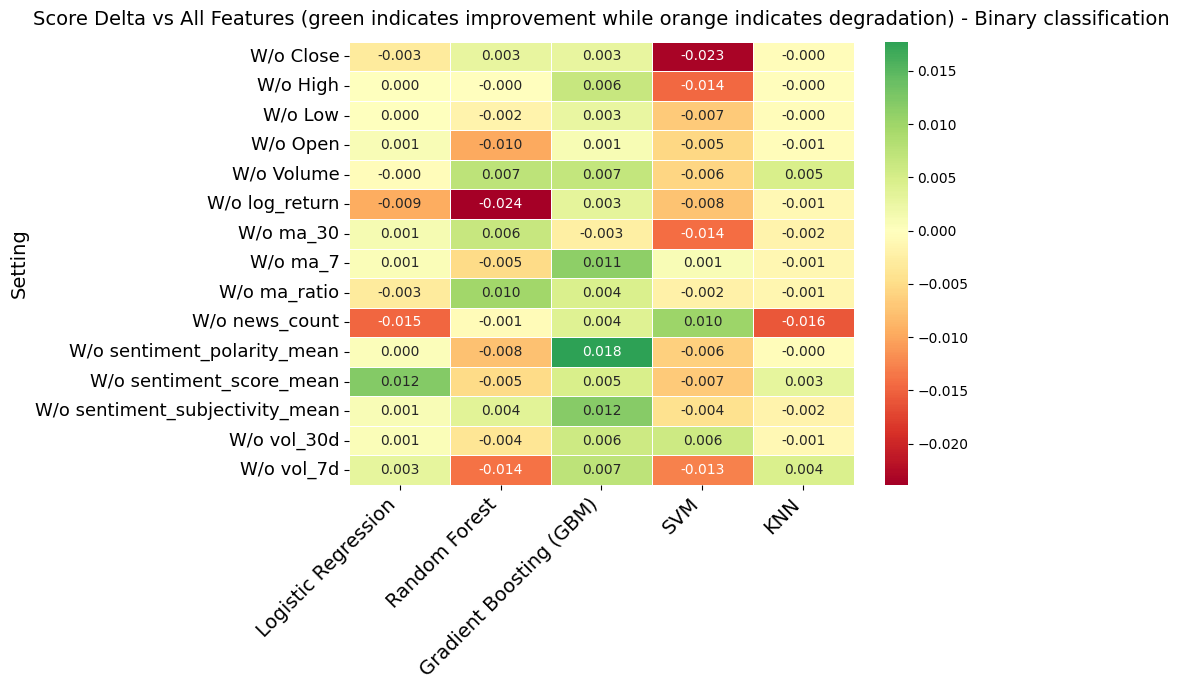

In [29]:
# Delta heatmap: Illustrate the impact of each feature to model performance
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(delta_df, annot=True, fmt=".3f",
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Score Delta vs All Features (green indicates improvement while orange indicates degradation) - Binary classification', fontsize=14, pad=12)
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right',fontsize=14)
plt.yticks(fontsize=13)
plt.ylabel("Setting", fontsize=14)
plt.tight_layout()

In general, the importance of each feature is vary across models.

- In logistic regression model, the model is most rely on `the number of news` and `log return` on the previous day to predict whether the close price of that token increases on the following day. Particularly, dropping `the number of news` and `log return` decrease the performance of model by `0.015` and `0.009` respectively. In contrast, `mean sentiment score` is considered as a noise to the model, when dropping it increase the model performance by `0.012`. Dropping other features impact the model performance slightly 

- In the random forest model, `log return` is the most critical feature, removing it causes the largest performance drop of `0.024`. `Vol 7d`, `Open price` and `sentiment popularity mean` also contribute meaningfully, with their removal degrading performance by `0.014`, `0.010` and `0.008` respectively. Removing `ma ratio` and `volumne` slightly improves performance by `0.010` and `0.007`, suggesting they introduce minor noise. Other features have negligible impact.

- For GBM, only `ma 30` is considered important to the model, while the remaining features are considered as noise. Especially, removing `sentiment score mean`, `sentiment subject mean` and `ma 7` improves the performance of the mdoe by `0.018` , `0.012` and `0.011` respectively.
  - We attribute this observation to the fact that both GBM is sensitive to redudant and irrelevant features. A smaller but more carefully selected subset of features would likely yield better and more stable performance than using all features together.

-  In the SVM model, `Close price`, `highest price`, `ma 30` and `vol 7d` previous day are the most critical features, with their removal degrading performance by `0.023`, `0.014`, `0.014` and `0.013` respectively. `low price` and `log return` also contribute meaningfully, with drops of `0.007` and `0.008` upon removal. In contrast, `news count` acts as a beneficial feature when dropped, improving performance by `0.010`, suggesting it introduces noise. 

- In the KNN model, `news_count` is the most critical feature, with its removal causing the largest performance drop of `0.016`. Other features and sentiment-related features have negligible or marginal impact on the model.



We then retrieve importance score from randomforest to compare and contrast


In [30]:
task = BINARY_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "random_forest_feat_importance_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    random_forest_feat_importance_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    random_forest_feat_importance_binary_df = feature_important_score_by_random_forest(files, task,RandomForestClassifier())
    random_forest_feat_importance_binary_df.to_csv(result_path_file,index=False)


random_forest_feat_importance_binary_df.head(32)


INFO: LOADED existing results


,feature,importance
0,log_return,0.087101
1,sentiment_subjectivity_mean,0.078099
2,sentiment_polarity_mean,0.073594
3,Volume,0.071577
4,vol_7d,0.069622
5,ma_ratio,0.068177
6,sentiment_score_mean,0.067824
7,vol_30d,0.064836
8,Close,0.064370
9,ma_7,0.061766


Text(0.5, 0, 'Important score')

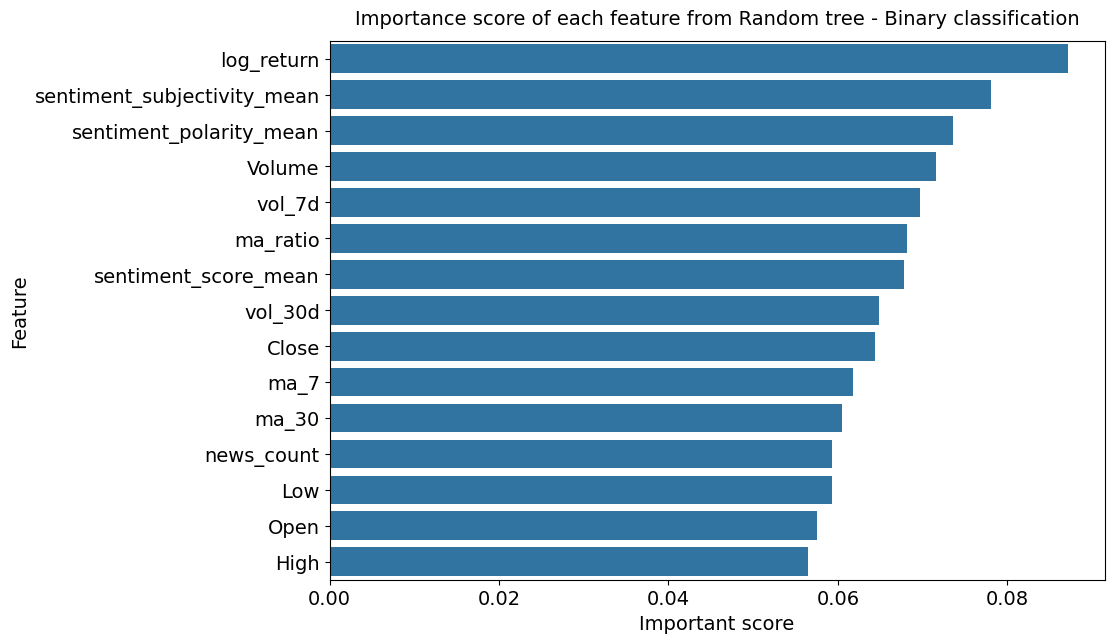

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=random_forest_feat_importance_binary_df,x='importance',y='feature')
ax.set_title('Importance score of each feature from Random tree - Binary classification', fontsize=14, pad=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.xlabel("Important score",fontsize=14)

This result indicates `log return` is the most important feature for random forest, which align with observation that removing `log return` decreases the model performance the most. However, for many other features, their high importance score does not translate to a large performance drop when removed because correlated features can substitute for each other. For example, `Close`, `High`, `Low`, and `Open` are highly correlated, so when one is dropped the others compensate, making the individual drop experiment show little performance change despite each having moderate importance scores.

We attribute this observation due to the fact that: the importance score of random forest reflect how frequently and how effectively a feature is used during training to split nodes across all trees. However, it doesn't reflect how much the features contributes to the prediction on unseen data in test set, as droppring feature experiment reflects.

Next, we study the performance of each model accross 40 token networks 

Text(0, 0.5, 'AUC')

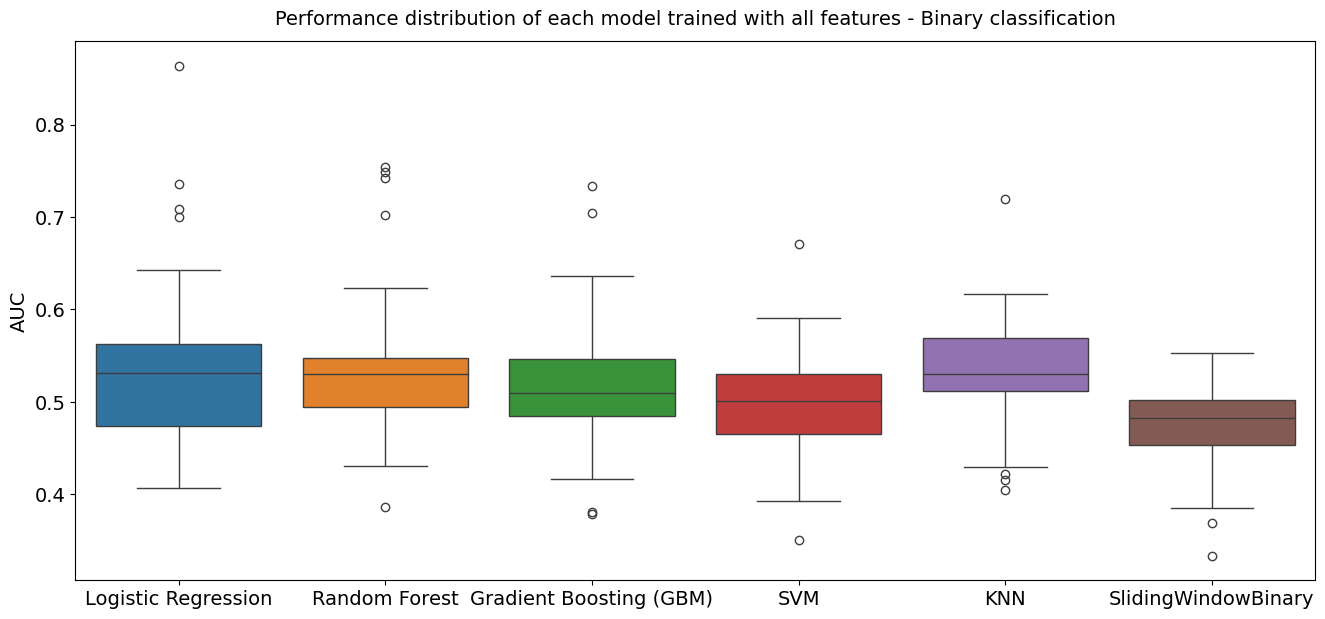

In [32]:
all_rows = []
for dataset in all_models_feat_importance_binary_df['Dataset'].unique().tolist():
    for model in model_cols:
        performance = all_models_feat_importance_binary_df[(all_models_feat_importance_binary_df['Dataset'] == dataset) &
                                                           (all_models_feat_importance_binary_df['Setting'] == 'All features')][model]
        all_rows.append({'Model': model, 'Dataset': dataset, 'Performance (AUC)': performance.values[0]})

tmp_df = pd.concat([pd.DataFrame(all_rows),sliding_window_binary_df],ignore_index=True)

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_title('Performance distribution of each model trained with all features - Binary classification', fontsize=14, pad=12)
sns.boxplot(data=tmp_df,y='Performance (AUC)',hue='Model',x='Model')
plt.xlabel("")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("AUC", fontsize=14)

Across all five models, median AUC scores range from approximately `0.50` to `0.54`, hovering close to the random chance baseline of `0.50`, indicating that no model achieves strong predictive performance with the current feature set. Random Forest yields the highest median AUC but also the widest spread, suggesting inconsistent performance across different tokens. GBM is the most stable model with the tightest distribution, while SVM performs the worst, occasionally dropping as low as `0.10`. The high-end outliers present in all models suggest that predictability varies greatly across tokens, with some being more predictable than others. Overall, the results reflect the inherently noisy and unpredictable nature of cryptocurrency price movements.

In [33]:
filter_performance = tmp_df[tmp_df['Performance (AUC)'] >= 0.7]

display(filter_performance)

good_performance_datasets_list = list(filter_performance['Dataset'].unique())
performance_datasets_split = prepare_datasets(good_performance_datasets_list,ALL_FEAT_COLUMN, BINARY_LABEL_COLUMN)

# Compute label ratio of each dataset that has high model performance
rows = []
for train, val, test in performance_datasets_split:
    num_ones = test.y.sum().item()
    num_zeros = (test.y == 0).sum().item()
    total = len(test.y)

    rows.append({
        'Dataset': train.dataset_name,
        '1 (%)': f"{num_ones/total*100:.1f}%",
        '0 (%)': f"{num_zeros/total*100:.1f}%"
    })

df_label_balance = pd.DataFrame(rows)
display(df_label_balance)


,Model,Dataset,Performance (AUC)
145,Logistic Regression,pepe.csv,0.863636
146,Random Forest,pepe.csv,0.742424
149,KNN,pepe.csv,0.719697
170,Logistic Regression,shiba_inu.csv,0.700000
190,Logistic Regression,sui.csv,0.735294
191,Random Forest,sui.csv,0.702614
210,Logistic Regression,the_graph.csv,0.708333
211,Random Forest,the_graph.csv,0.754167
212,Gradient Boosting (GBM),the_graph.csv,0.733333
231,Random Forest,usd_coin.csv,0.748727


,Dataset,1 (%),0 (%)
0,pepe.csv,5.7%,94.3%
1,shiba_inu.csv,8.6%,91.4%
2,sui.csv,51.4%,48.6%
3,the_graph.csv,54.5%,45.5%
4,usd_coin.csv,45.7%,54.3%


Interestingly, two tokens, `pepe` and `shiba_inu`, have significant label imbalance, with the positive class (label 1) accounting for only 5.7% and 8.6% of samples respectively. This imbalance explains the unusually high AUC scores observed for these tokens, particularly `pepe`, where Logistic Regression and Random Forest achieve AUC scores of `0.863`and `0.742` respectively.

### 2.2 Regression setting

In the following section, we aim to answer the following research question:

> II. How do traditional machine learning models such as Linear Regression, Ridge, Lasso, Random Forest (regression version), GBM and SVR perform in predicting `close price` of a token in the following day (regression)? What is the importance of each feature contributing to the prediction?

Similar to binary classification setting, to answer that research question, we design the experiment as follow:

1. We train and evaluate all traditional machine learning models on train and test split, respectively, with all features defined in `ALL_FEAT_COLUMN`
2. Then we drop each feature one by one and perform the first step again to observe the performance change

In addition to dropping featrues experiment, we also retrieve the features importance from random forest to compare and contrast

First, we conduct dropping features experiment

In [34]:

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
task = REGRESSION_LABEL_COLUMN
RE_RUN_EVERYTHING=False
seed_everything(INIT_SEED)

result_file_name = "all_models_feat_importance_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    all_models_feat_importance_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_models_feat_importance_regression_df = drop_feature_experiment(files, task,regression_classfication_model_experiment)
    all_models_feat_importance_regression_df.to_csv(result_path_file,index=False)


all_models_feat_importance_regression_df.head(60)



INFO: LOADED existing results


,Linear Regression,Ridge,Lasso,Random Forest,Gradient Boosting (GBM),SVR,Setting,Dataset
0,0.169011,0.173035,0.170190,0.182736,0.175984,0.494986,All features,aave.csv
1,0.239314,0.305518,1.505493,0.228544,0.263682,1.120839,All features,algorand.csv
2,0.178616,0.176585,0.191758,0.190497,0.193734,0.310100,All features,aptos.csv
3,0.180159,0.164766,0.222657,0.184797,0.208607,0.253315,All features,arbitrum.csv
4,0.209219,0.259313,0.209640,0.303646,0.448660,0.815670,All features,avalanche.csv
5,0.210605,0.319269,0.256181,0.267883,0.316330,1.078266,All features,axie_infinity.csv
6,0.122197,0.134753,0.118414,0.154364,0.151518,0.598741,All features,binance_coin.csv
7,0.124545,0.135428,0.124168,0.178158,0.174810,0.394090,All features,bitcoin.csv
8,0.151806,0.163198,0.146569,0.210740,0.185615,0.607477,All features,bitcoin_cash.csv
9,0.164804,0.194976,0.873202,0.171689,0.192229,0.676995,All features,cardano.csv


Now compute the performance of the baseline

In [35]:
seed_everything(INIT_SEED)
task = REGRESSION_LABEL_COLUMN

result_file_name = "sliding_window_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    sliding_window_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)
    sliding_window_baseline_all_rows = []
    for train, val,test in tqdm(all_data_split):
        result = sliding_window_baseline(train,val,test,binary_classification=False,metric=mean_absolute_percentage_error)
        sliding_window_baseline_all_rows.append({'Model': "SlidingWindowRegression", 'Dataset': train.dataset_name, 'Performance (MAPE)': result})

    sliding_window_regression_df = pd.DataFrame(sliding_window_baseline_all_rows)
    sliding_window_regression_df.to_csv(result_path_file, index= False)


sliding_window_regression_df.head(10)

INFO: LOADED existing results


,Model,Dataset,Performance (MAPE)
0,SlidingWindowRegression,aave.csv,0.043840
1,SlidingWindowRegression,algorand.csv,0.044069
2,SlidingWindowRegression,aptos.csv,0.048750
3,SlidingWindowRegression,arbitrum.csv,0.040497
4,SlidingWindowRegression,avalanche.csv,0.064411
5,SlidingWindowRegression,axie_infinity.csv,0.039081
6,SlidingWindowRegression,binance_coin.csv,0.020911
7,SlidingWindowRegression,bitcoin.csv,0.026426
8,SlidingWindowRegression,bitcoin_cash.csv,0.036199
9,SlidingWindowRegression,cardano.csv,0.041878


The performance of model is reported with Mean Absolute Percentage Error (MAPE) metric.

Next, we plot diagram from the results and interpret the results

In [36]:
model_cols = ['Linear Regression', 'Ridge','Lasso','Random Forest', 'Gradient Boosting (GBM)', 'SVR']

# Compute average performance of each model across dataset for each setting
df_setting_avg = all_models_feat_importance_regression_df.groupby('Setting')[model_cols].mean().reset_index()

# Baseline setting where all features are included
baseline = df_setting_avg[df_setting_avg['Setting'] == 'All features'].set_index('Setting')

# Compute the delta
delta_df = baseline.values - df_setting_avg.set_index('Setting')[model_cols] # Smaller is better
delta_df = delta_df.drop('All features')

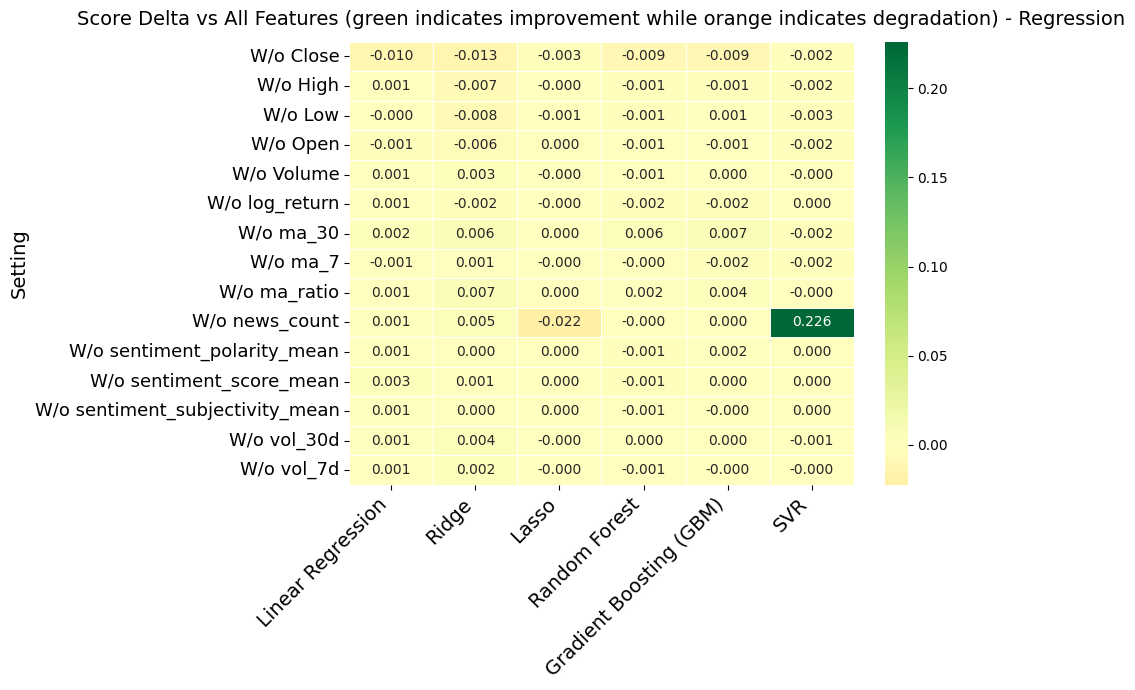

In [37]:
# Delta heatmap: Illustrate the impact of each feature to model performance
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(delta_df, annot=True, fmt=".3f",
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Score Delta vs All Features (green indicates improvement while orange indicates degradation) - Regression', fontsize=14, pad=12)
ax.set_xlabel('Models')
plt.xticks(rotation=45, ha='right',fontsize=14)
plt.ylabel("Setting", fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("")
plt.tight_layout()

- Overall, for Linear Regression, Ridge, Random Forest and GBM, removing most features have near-zero impact.
- Lasso nearly all deltas are at or near zero, except `the number of news` (`-0.022`), which is the most important feature across all regression models.
- While new count is a important feature for Lasso, SVR considers `the number of news` to be the most noisy feature. Since removing `the number of news count` improve the performance of the model significantly by `0.226`

We then retrieve importance score from randomforest to compare and contrast

In [38]:
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "random_forest_feat_importance_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    random_forest_feat_importance_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    random_forest_feat_importance_regression_df = feature_important_score_by_random_forest(files, task,RandomForestRegressor())
    random_forest_feat_importance_regression_df.to_csv(result_path_file,index=False)


random_forest_feat_importance_regression_df.head(32)

INFO: LOADED existing results


,feature,importance
0,Close,0.510088
1,High,0.231965
2,Low,0.133066
3,Open,0.073419
4,ma_30,0.013327
5,ma_7,0.009653
6,vol_30d,0.006138
7,log_return,0.004919
8,Volume,0.004337
9,vol_7d,0.004077


Text(0.5, 0, 'Important score')

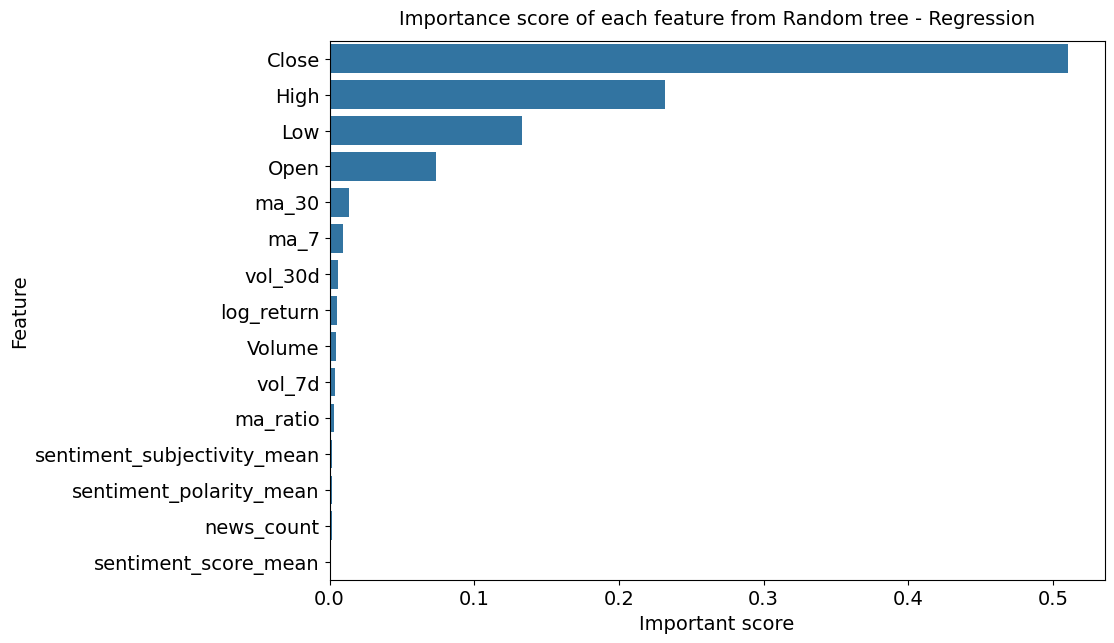

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=random_forest_feat_importance_regression_df,x='importance',y='feature')
ax.set_title('Importance score of each feature from Random tree - Regression', fontsize=14, pad=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.xlabel("Important score",fontsize=14)

- Different from Random forest in the case of binary classification, in which the importance scores are distributed approximately equal to each feature and weighted the most on `log return`, Random forest in regression considers `close`, `high`, `low` and `open` prices are the most importance features. In particular, random forest finds `close price` of previous day most importance. 

Next, we study the performance of each model accross 40 token networks

Text(0.5, 0, '')

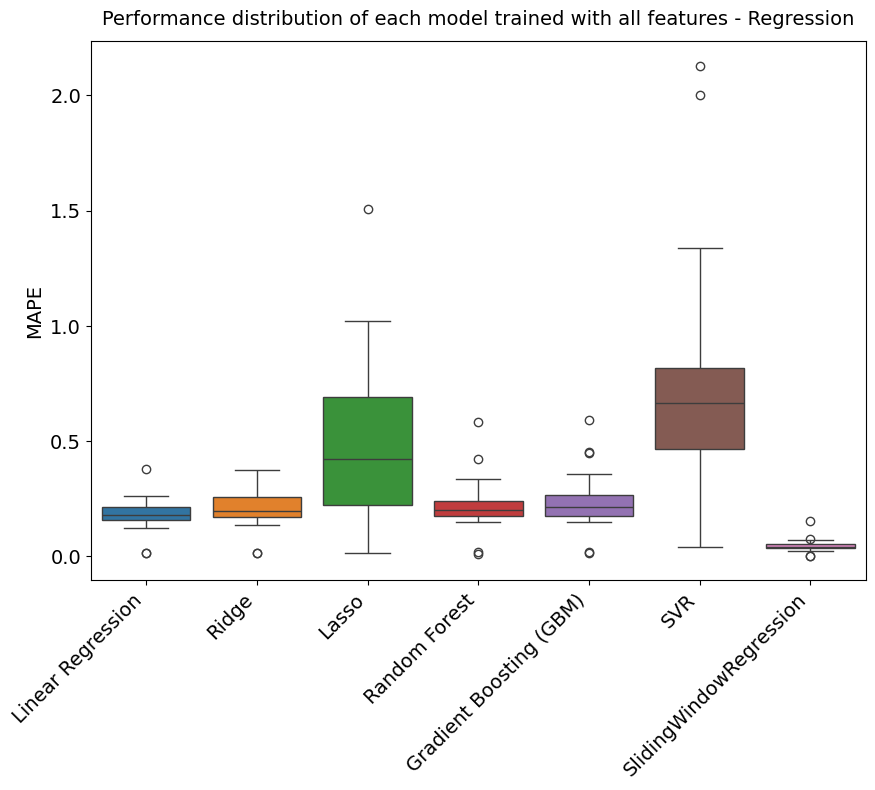

In [40]:
all_rows = []
for dataset in all_models_feat_importance_regression_df['Dataset'].unique().tolist():
    for model in model_cols:
        performance = all_models_feat_importance_regression_df[(all_models_feat_importance_regression_df['Dataset'] == dataset) &
                                                           (all_models_feat_importance_regression_df['Setting'] == 'All features')][model]
        all_rows.append({'Model': model, 'Dataset': dataset, 'Performance (MAPE)': performance.values[0]})

tmp_df = pd.concat([pd.DataFrame(all_rows),sliding_window_regression_df],ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title('Performance distribution of each model trained with all features - Regression', fontsize=14, pad=12)
sns.boxplot(data=tmp_df,y='Performance (MAPE)',hue='Model',x='Model')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("MAPE", fontsize=14)
plt.xticks(rotation=45, ha='right',fontsize=14)

plt.xlabel("")

- Lasso and SVR are the worst models among all
- Suprisingly, by predicing the average closing prices of the last 7 days, Sliding window baseline is the most stable and the best model among models
- Linear regression is the second best model

In [41]:
filter_performance_suspicious_high = tmp_df[tmp_df['Performance (MAPE)'] >= 1.5]
filter_performance_suspicious_low = tmp_df[tmp_df['Performance (MAPE)'] <= 0.1]

print("Dataset that has suspicious high MAPE")
display(filter_performance_suspicious_high)

print("Dataset that has suspicious low MAPE")
display(filter_performance_suspicious_low)

good_performance_datasets_list = list(filter_performance_suspicious_low['Dataset'].unique())
bad_performance_datasets_list = list(filter_performance_suspicious_high['Dataset'].unique())

Dataset that has suspicious high MAPE


,Model,Dataset,Performance (MAPE)
8,Lasso,algorand.csv,1.505493
209,SVR,shiba_inu.csv,2.128883
287,SVR,vechain.csv,2.003354


Dataset that has suspicious low MAPE


,Model,Dataset,Performance (MAPE)
234,Linear Regression,tether.csv,0.014574
235,Ridge,tether.csv,0.014158
236,Lasso,tether.csv,0.016159
237,Random Forest,tether.csv,0.014736
238,Gradient Boosting (GBM),tether.csv,0.014837
239,SVR,tether.csv,0.040487
276,Linear Regression,usd_coin.csv,0.011437
277,Ridge,usd_coin.csv,0.011143
278,Lasso,usd_coin.csv,0.012088
279,Random Forest,usd_coin.csv,0.009669


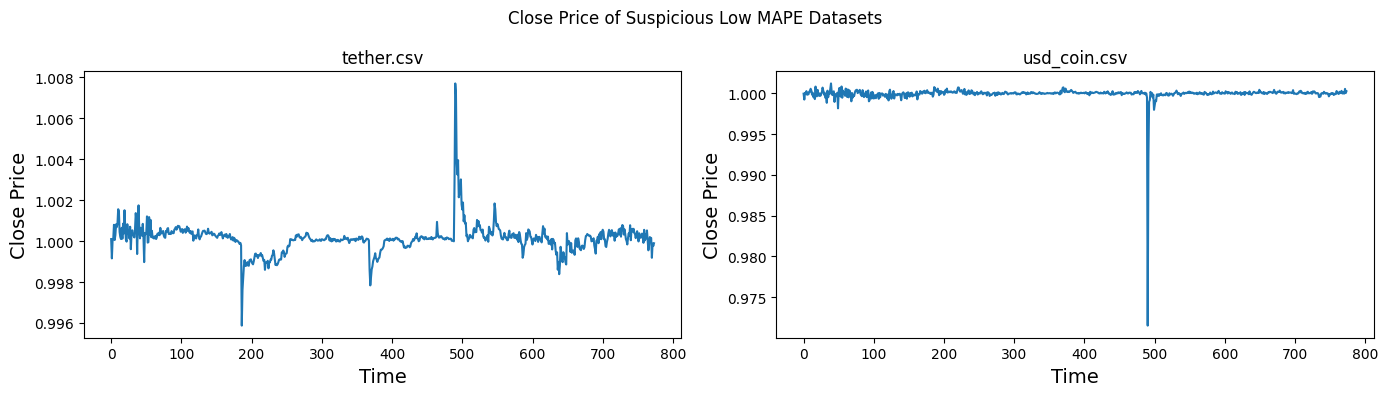

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, dataset_name in zip(axes, good_performance_datasets_list):
    df = pd.read_csv(os.path.join(DATA_PATH,dataset_name))
    ax.plot(df['Close'])
    ax.set_title(dataset_name)
    ax.set_xlabel('Time',fontsize=14)
    ax.set_ylabel('Close Price',fontsize=14)

plt.suptitle('Close Price of Suspicious Low MAPE Datasets')
plt.tight_layout()

plt.show()

- From crypto currencies context, both Both Tether (USDT) and USD Coin (USDC) are stablecoins, whose prices are maintained to be stable over the time. This indicates the price of these tokens, especially USDC, are stable and easy to predict for traditional ML models.

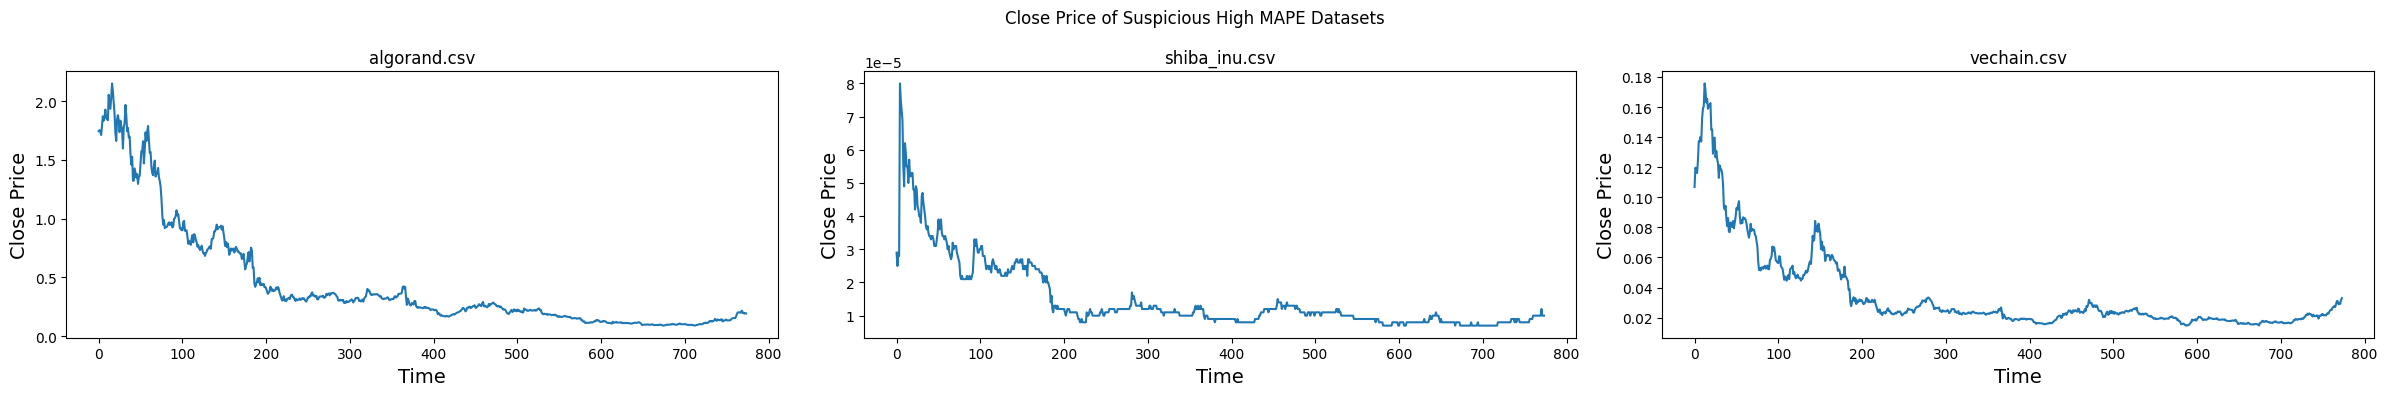

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(24, 4))

for ax, dataset_name in zip(axes, bad_performance_datasets_list):
    df = pd.read_csv(os.path.join(DATA_PATH,dataset_name))
    ax.plot(df['Close'])
    ax.set_title(dataset_name)
    ax.set_xlabel('Time',fontsize=14)
    ax.set_ylabel('Close Price',fontsize=14)

plt.suptitle('Close Price of Suspicious High MAPE Datasets')
plt.tight_layout()
plt.show()

- All three tokens share the same boom-and-bust pattern: prices peaked dramatically during training and never recovering during testing period.
- The statistical properties shift drastically before and after the crash, meaning models trained on one regime generalize poorly to the other.

### 2.3 Time series baseline

In the following section, we aim to answer the following research question:

> Can time-series model such as ARIMA performs better in regression task?

In [44]:
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "mape_arima_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    arima_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)

    all_rows_arima = []
    for train, val, test in tqdm(all_data_split):
        mape, preds = arima_baseline(train,val,test)
        all_rows_arima.append({'Dataset' : train.dataset_name, 'MAPE': mape})
    
    arima_df = pd.DataFrame(all_rows_arima)
    arima_df.to_csv(result_path_file, index= False)


arima_df.head(32)

INFO: LOADED existing results


,Dataset,MAPE
0,aave.csv,0.028158
1,algorand.csv,0.035703
2,aptos.csv,0.035907
3,arbitrum.csv,0.031034
4,avalanche.csv,0.031384
5,axie_infinity.csv,0.040927
6,binance_coin.csv,0.013351
7,bitcoin.csv,0.014562
8,bitcoin_cash.csv,0.024455
9,cardano.csv,0.022541


Now we merge performance of ARIMA with other baseline for comparision

In [45]:
all_models_feat_importance_regression_df_filter = all_models_feat_importance_regression_df[all_models_feat_importance_regression_df['Setting'] == 'All features']
combined_result = pd.merge(left=arima_df, right=all_models_feat_importance_regression_df_filter,left_on='Dataset', right_on='Dataset')
combined_result = combined_result.rename(columns = {'MAPE': 'ARIMA'}).drop(columns=['Setting'])

combined_result = pd.merge(left = combined_result,right = sliding_window_regression_df,left_on='Dataset', right_on='Dataset')
combined_result = combined_result.rename(columns = {'Performance (MAPE)': 'SlidingWindowRegression'}).drop(columns=['Model'])


combined_result

,Dataset,ARIMA,Linear Regression,Ridge,Lasso,Random Forest,Gradient Boosting (GBM),SVR,SlidingWindowRegression
0,aave.csv,0.028158,0.169011,0.173035,0.170190,0.182736,0.175984,0.494986,0.043840
1,algorand.csv,0.035703,0.239314,0.305518,1.505493,0.228544,0.263682,1.120839,0.044069
2,aptos.csv,0.035907,0.178616,0.176585,0.191758,0.190497,0.193734,0.310100,0.048750
3,arbitrum.csv,0.031034,0.180159,0.164766,0.222657,0.184797,0.208607,0.253315,0.040497
4,avalanche.csv,0.031384,0.209219,0.259313,0.209640,0.303646,0.448660,0.815670,0.064411
5,axie_infinity.csv,0.040927,0.210605,0.319269,0.256181,0.267883,0.316330,1.078266,0.039081
6,binance_coin.csv,0.013351,0.122197,0.134753,0.118414,0.154364,0.151518,0.598741,0.020911
7,bitcoin.csv,0.014562,0.124545,0.135428,0.124168,0.178158,0.174810,0.394090,0.026426
8,bitcoin_cash.csv,0.024455,0.151806,0.163198,0.146569,0.210740,0.185615,0.607477,0.036199
9,cardano.csv,0.022541,0.164804,0.194976,0.873202,0.171689,0.192229,0.676995,0.041878


For each dataset, we compute the rank of each model according to their MAPE (i.e the best model (the lowest MAPE) has the rank of 1)

In [46]:
model_cols = ['ARIMA', 'Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting (GBM)', 'SVR','SlidingWindowRegression']

rank_df = combined_result[model_cols].rank(axis=1, method='min').astype(int)
rank_df.columns = [f'{col} Rank' for col in model_cols]
rank_df.insert(0, 'Dataset', combined_result['Dataset'])
rank_df['Best Model'] = combined_result[model_cols].idxmin(axis=1)
rank_df

,Dataset,ARIMA Rank,Linear Regression Rank,Ridge Rank,Lasso Rank,Random Forest Rank,Gradient Boosting (GBM) Rank,SVR Rank,SlidingWindowRegression Rank,Best Model
0,aave.csv,1,3,5,4,7,6,8,2,ARIMA
1,algorand.csv,1,4,6,8,3,5,7,2,ARIMA
2,aptos.csv,1,4,3,6,5,7,8,2,ARIMA
3,arbitrum.csv,1,4,3,7,5,6,8,2,ARIMA
4,avalanche.csv,1,3,5,4,6,7,8,2,ARIMA
5,axie_infinity.csv,2,3,7,4,5,6,8,1,SlidingWindowRegression
6,binance_coin.csv,1,4,5,3,7,6,8,2,ARIMA
7,bitcoin.csv,1,4,5,3,7,6,8,2,ARIMA
8,bitcoin_cash.csv,1,4,5,3,7,6,8,2,ARIMA
9,cardano.csv,1,3,6,8,4,5,7,2,ARIMA


Then, we compute the average rank accross all token networks

In [47]:
rank_df.mean(numeric_only=True).round(2)


ARIMA Rank                      1.04
Linear Regression Rank          3.63
Ridge Rank                      4.82
Lasso Rank                      6.33
Random Forest Rank              5.02
Gradient Boosting (GBM) Rank    5.43
SVR Rank                        7.78
SlidingWindowRegression Rank    1.96
dtype: float64

Interestingly, by predicting the average close price of last seven day, sliding window regression is the best model with the average rank of `1.01`.

ARIMA achieves the best average rank of `3.06`, closely followed by Linear Regression at `3.33`, making these the two strongest models for price prediction across all token networks. Ridge ranks third at `4.59`, while Random Forest and GBM perform similarly at `4.82` and `5.24` respectively. Lasso and SVR are the weakest performers with average ranks of `6.16` and `7.78`.

TThis suggests that simpler linear models generalize better than complex ensemble or kernel-based methods for this regression task, likely because the current feature set does not contain enough non-linear signal to justify the additional complexity. Notably, ARIMA, the only model that explicitly incorporates temporal autocorrelation, ranks highest overall, suggesting that time dependency in cryptocurrency prices is an important signal that the ML models, which treat each sample independently, fail to fully capture.

## Neural network

Next we experiment predicting next close price with neural networks. In this project, we experiment Recurrent Neural Network (RNN) and its variants Gated Recurrent Unit (GRU). Below, we define the support function as follows:

*Note: We use default hyperparameters and do not perform hyperparameters tunning due to time and resource constraint.*

1. Collate dataset

In [50]:
def collate_dataset(data: TimeSeriesDataset) -> Tuple[np.ndarray, np.ndarray]:
    r"""
    Iterate over a TimeSeriesDataset and stack into numpy arrays to make dataset compatible with models from Tensorflow
    Returns:
        - `X`:(N, window_size, num_features) combined input features
        - `y`:(N,)  combined labels
    """
    xs, ys = [], []
    for _, x, y in data:
        xs.append(x)
        ys.append(y)
    X = np.array(xs, dtype=np.float32)            # (N, window_size, num_features)
    y = np.array(ys, dtype=np.float32).squeeze()  # (N,)
    return X, y

2. Build keras models: RNN and GRU

In [51]:
def build_rnn(
        window_size: int,
        num_features: int,
        dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
) -> keras.Model:
    r"""
    Stacked SimpleRNN for regression.

    Args:
        - `window_size`: sequence length, must match dataset window_size
        - `num_features`: number of input features
        - `dim`: hidden units per layer
        - `num_layers`: number of stacked RNN layers
        - `dropout`: dropout rate between layers

    Returns: uncompiled Keras model
    """
    inputs = keras.Input(shape=(window_size, num_features), name="input")
    x = inputs
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        x = layers.SimpleRNN(dim, return_sequences=return_seq, name=f"rnn_{i+1}")(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    outputs = layers.Dense(1, activation="linear", name="output")(x)
    return keras.Model(inputs, outputs, name="SimpleRNN")


def build_gru(
        window_size: int,
        num_features: int,
        dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
) -> keras.Model:
    r"""
    Stacked GRU for regression.

    Args:(same as build_rnn)

    Returns: uncompiled Keras model
    """
    inputs = keras.Input(shape=(window_size, num_features), name="input")
    x = inputs
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        x = layers.GRU(dim, return_sequences=return_seq, name=f"gru_{i+1}")(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    outputs = layers.Dense(1, activation="linear", name="output")(x)
    return keras.Model(inputs, outputs, name="GRU")

3. Evaluate nn models

In [52]:
def evaluate_model(
        test_data: TimeSeriesDataset,
        model: keras.Model,
        batch_size: int = 64,
) -> float:
    r"""
    Evaluate a trained Keras regression model, reporting MAPE.

    Note: sklearn MAPE returns a decimal.
    Args:
        - `test_data`: test TimeSeriesDataset
        - `model`: trained Keras model
        - `batch_size`: batch size for inference

    Returns: MAPE score(float)
    """
    X_test, y_test = collate_dataset(test_data)
    preds = model.predict(X_test, batch_size=batch_size, verbose=0).squeeze()
    mape  = mean_absolute_percentage_error(y_test, preds)
    return mape


4. Train nn models

In [55]:
def train_model(
        train_data: TimeSeriesDataset,
        val_data: TimeSeriesDataset,
        model: keras.Model,
        epochs: int = 100,
        batch_size: int = 64,
        patience: int = 10,
) -> keras.callbacks.History:
    r"""
    Train a Keras regression model with early stopping and LR reduction.

    Args:
        - `train_data`: training TimeSeriesDataset
        - `val_data`: validation TimeSeriesDataset
        - `model`: compiled Keras model
        - `epochs`: maximum training epochs
        - `batch_size`: mini-batch size
        - `patience`: early stopping patience (monitors val_loss)

    Returns: Keras History object
    """
    X_train, y_train = collate_dataset(train_data)
    X_val,   y_val   = collate_dataset(val_data)

    callbacks = [
        keras.callbacks.EarlyStopping( # Early stoppting on validation loss
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau( # Scheduler
            monitor='val_loss',
            factor=0.5,
            patience=5,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )
    return history

5. Use `train_model` and `evaluate_model` to run regression experiment

In [56]:
def rnn_regression_experiment(
        train_data: TimeSeriesDataset,
        val_data: TimeSeriesDataset,
        test_data: TimeSeriesDataset,
        num_features: int,
        window_size: int,
        model_type: str = 'gru',
        dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
        lr: float = 1e-3,
        epochs: int = 100,
        batch_size: int = 64,
        patience: int = 10,
) -> float:
    r"""
    End-to-end regression experiment with RNN or GRU, reporting MAPE.

    Args:
        - `train_data`: training split
        - `val_data`: validation split
        - `test_data`: test split
        - `num_features`: number of input features
        - `window_size`: sequence length, must match dataset window_size
        - `model_type`: 'rnn' or 'gru'
        - `dim`: hidden size per layer
        - `num_layers`: number of stacked layers
        - `dropout`: dropout rate
        - `lr`: learning rate
        - `epochs`: max training epochs
        - `batch_size`: batch size
        - `patience`: early stopping patience

    Returns: MAPE as a percentage (float)
    """
    build_fn = build_rnn if model_type == 'rnn' else build_gru
    model = build_fn(window_size, num_features, dim, num_layers, dropout)

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae'],
    )
    train_model(train_data, val_data, model, epochs, batch_size, patience)

    mape = evaluate_model(test_data, model, batch_size)
    return mape


Now we merge `RNN` and `GRU` results with previous results of traditional machine learning models and ARIMA

In [67]:
result_file_name = "mape_nn_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    nn_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    all_results = []
    all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, REGRESSION_LABEL_COLUMN, window_size=WINDOW_SIZE)

    for train,val,test in tqdm(all_data_split):
        for model_type in ['gru','rnn']:
            mape = rnn_regression_experiment(
                train_data=train,
                val_data=val,
                test_data=test,
                num_features=len(ALL_FEAT_COLUMN),
                window_size=WINDOW_SIZE,
                model_type=model_type,
                batch_size=16
            )
            all_results.append({
                'Dataset': train.dataset_name,
                'Model':   model_type.upper(),
                'MAPE':     mape,
            })

    nn_df = pd.DataFrame(all_results)
    nn_df.to_csv(result_path_file, index= False)

nn_df.head(30)

INFO: LOADED existing results


,Dataset,Model,MAPE
0,aave.csv,GRU,0.197862
1,aave.csv,RNN,0.198323
2,algorand.csv,GRU,0.279232
3,algorand.csv,RNN,0.478769
4,aptos.csv,GRU,0.083832
5,aptos.csv,RNN,0.083679
6,arbitrum.csv,GRU,0.059646
7,arbitrum.csv,RNN,0.098715
8,avalanche.csv,GRU,0.404330
9,avalanche.csv,RNN,0.329335


In [58]:

tmp_combine = pd.merge(left=combined_result, right=nn_df[nn_df['Model'] == 'GRU'],left_on='Dataset', right_on='Dataset')
tmp_combine = tmp_combine.rename(columns = {'MAPE': 'GRU'}).drop(columns=['Model'])
tmp_combine

tmp_combine = pd.merge(left=tmp_combine, right=nn_df[nn_df['Model'] == 'RNN'],left_on='Dataset', right_on='Dataset')
combined_result_with_nn = tmp_combine.rename(columns = {'MAPE': 'RNN'}).drop(columns=['Model'])
combined_result_with_nn

,Dataset,ARIMA,Linear Regression,Ridge,Lasso,Random Forest,Gradient Boosting (GBM),SVR,SlidingWindowRegression,GRU,RNN
0,aave.csv,0.028158,0.169011,0.173035,0.170190,0.182736,0.175984,0.494986,0.043840,0.197862,0.198323
1,algorand.csv,0.035703,0.239314,0.305518,1.505493,0.228544,0.263682,1.120839,0.044069,0.279232,0.478769
2,aptos.csv,0.035907,0.178616,0.176585,0.191758,0.190497,0.193734,0.310100,0.048750,0.083832,0.083679
3,arbitrum.csv,0.031034,0.180159,0.164766,0.222657,0.184797,0.208607,0.253315,0.040497,0.059646,0.098715
4,avalanche.csv,0.031384,0.209219,0.259313,0.209640,0.303646,0.448660,0.815670,0.064411,0.404330,0.329335
5,axie_infinity.csv,0.040927,0.210605,0.319269,0.256181,0.267883,0.316330,1.078266,0.039081,0.990526,0.755177
6,binance_coin.csv,0.013351,0.122197,0.134753,0.118414,0.154364,0.151518,0.598741,0.020911,0.110402,0.112022
7,bitcoin.csv,0.014562,0.124545,0.135428,0.124168,0.178158,0.174810,0.394090,0.026426,0.992748,0.992767
8,bitcoin_cash.csv,0.024455,0.151806,0.163198,0.146569,0.210740,0.185615,0.607477,0.036199,0.230627,0.241101
9,cardano.csv,0.022541,0.164804,0.194976,0.873202,0.171689,0.192229,0.676995,0.041878,0.116621,0.261804


In [59]:
model_cols = ['ARIMA', 'Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting (GBM)', 'SVR','SlidingWindowRegression', 'RNN', 'GRU']

rank_df = combined_result_with_nn[model_cols].rank(axis=1, method='min').astype(int)
rank_df.columns = [f'{col} Rank' for col in model_cols]
rank_df.insert(0, 'Dataset', combined_result_with_nn['Dataset'])
rank_df['Best Model'] = combined_result_with_nn[model_cols].idxmin(axis=1)
rank_df

,Dataset,ARIMA Rank,Linear Regression Rank,Ridge Rank,Lasso Rank,Random Forest Rank,Gradient Boosting (GBM) Rank,SVR Rank,SlidingWindowRegression Rank,RNN Rank,GRU Rank,Best Model
0,aave.csv,1,3,5,4,7,6,10,2,9,8,ARIMA
1,algorand.csv,1,4,7,10,3,5,9,2,8,6,ARIMA
2,aptos.csv,1,6,5,8,7,9,10,2,3,4,ARIMA
3,arbitrum.csv,1,6,5,9,7,8,10,2,4,3,ARIMA
4,avalanche.csv,1,3,5,4,6,9,10,2,7,8,ARIMA
5,axie_infinity.csv,2,3,7,4,5,6,10,1,8,9,SlidingWindowRegression
6,binance_coin.csv,1,6,7,5,9,8,10,2,4,3,ARIMA
7,bitcoin.csv,1,4,5,3,7,6,8,2,10,9,ARIMA
8,bitcoin_cash.csv,1,4,5,3,7,6,10,2,9,8,ARIMA
9,cardano.csv,1,4,7,10,5,6,9,2,8,3,ARIMA


In [60]:
rank_df.mean(numeric_only=True).round(2)


ARIMA Rank                      1.04
Linear Regression Rank          4.24
Ridge Rank                      5.59
Lasso Rank                      7.55
Random Forest Rank              5.86
Gradient Boosting (GBM) Rank    6.33
SVR Rank                        9.51
SlidingWindowRegression Rank    2.00
RNN Rank                        7.18
GRU Rank                        5.69
dtype: float64

Surprisingly, `GRU` performs better only `Lasso`, `GBM` and `SVR`, while is significantly worse than `ARIMA`, `Linear Regression` and `Sliding window`. This may be resulted from not performing hyperparameters tuning for `GRU` and `RNN`. However, hyperparameters tunning on `RNN` and `GRU` can be time consuming. Hence, simple yet effective traditional machine learning models such as `Linear regression`, statistical model such as `ARIMA` or even heuristic baseline such as `Sliding window` are better choice in practical. 

Text(0.5, 0, '')

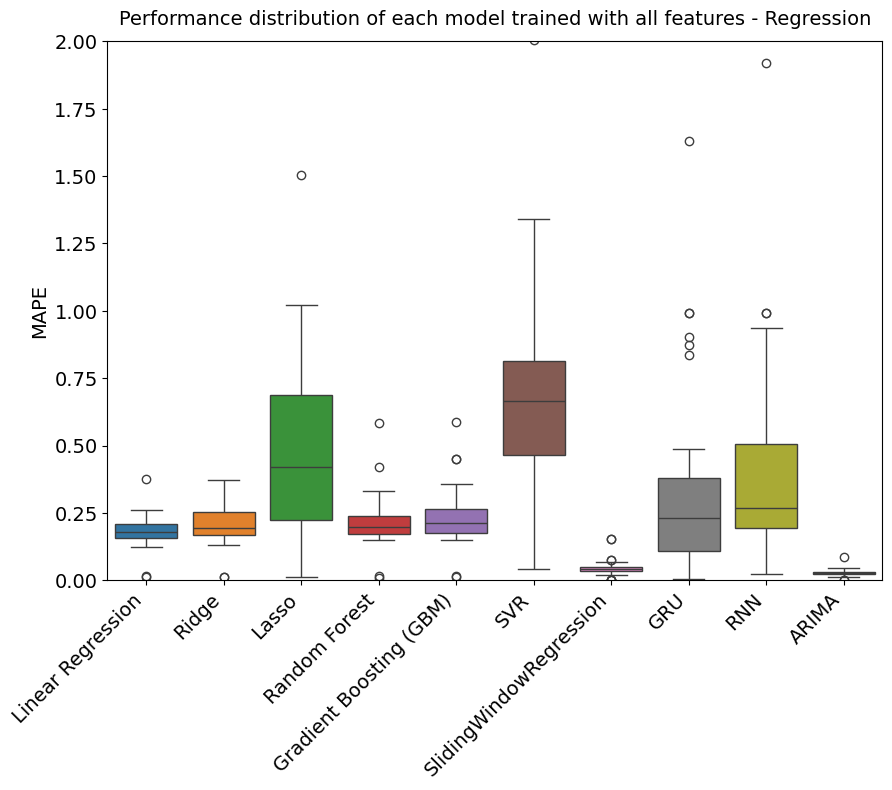

In [61]:
model_cols = ['Linear Regression', 'Ridge','Lasso','Random Forest', 'Gradient Boosting (GBM)', 'SVR', 'SlidingWindowRegression','GRU','RNN','ARIMA']

all_rows = []
for dataset in combined_result_with_nn['Dataset'].unique().tolist():
    for model in model_cols:
        performance = combined_result_with_nn[(combined_result_with_nn['Dataset'] == dataset)][model]
        all_rows.append({'Model': model, 'Dataset': dataset, 'Performance (MAPE)': performance.values[0]})

tmp_df = pd.concat([pd.DataFrame(all_rows),sliding_window_regression_df],ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title('Performance distribution of each model trained with all features - Regression', fontsize=14, pad=12)
sns.boxplot(data=tmp_df,y='Performance (MAPE)',hue='Model',x='Model')
ax.set_ylim(0, 2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("MAPE", fontsize=14)
plt.xticks(rotation=45, ha='right',fontsize=14)

plt.xlabel("")

## Time complexity experiment

In this section, we explore the time complexity of all regression models

We randomly select a token among 49 tokens and record the total training and inference time of each model as follows:

In [78]:
import timeit

def time_experiment(dataset = 'binance_coin.csv'):
    time_experiment_results = {}
    all_data_split = prepare_datasets([dataset], ALL_FEAT_COLUMN, REGRESSION_LABEL_COLUMN)
    train, val, test = all_data_split[0]

    start = timeit.default_timer()
    arima_baseline(train,val,test)
    duration = timeit.default_timer() - start
    time_experiment_results['ARIMA'] = duration

    start = timeit.default_timer()
    sliding_window_baseline(train,val,test,binary_classification=False,metric=mean_absolute_percentage_error)
    duration = timeit.default_timer() - start
    time_experiment_results['SlidingWindow'] = duration


    models = {
            "Linear Regression":       LinearRegression(),
            "Ridge":                   Ridge(alpha=1.0),
            "Lasso":                   Lasso(alpha=0.1),
            "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
            "Gradient Boosting (GBM)": GradientBoostingRegressor(n_estimators=100, random_state=42),
        }

    train_x = np.concatenate([train.x,val.x])
    train_y = np.concatenate([train.y.squeeze(),val.y.squeeze()])

    for name, model in models.items():
        start = timeit.default_timer()
        model.fit(train_x, train_y)
        model.predict(test.x)
        duration = timeit.default_timer() - start
        time_experiment_results[name] = duration

    all_data_split = prepare_datasets(['binance_coin.csv'], ALL_FEAT_COLUMN, REGRESSION_LABEL_COLUMN, window_size=WINDOW_SIZE)
    train, val, test = all_data_split[0]
    start = timeit.default_timer()
    rnn_regression_experiment(
                    train_data=train,
                    val_data=val,
                    test_data=test,
                    num_features=len(ALL_FEAT_COLUMN),
                    window_size=WINDOW_SIZE,
                    model_type='GRU',
                    batch_size=16
                )
    duration = timeit.default_timer() - start
    time_experiment_results['GRU'] = duration

    start = timeit.default_timer()
    rnn_regression_experiment(
                    train_data=train,
                    val_data=val,
                    test_data=test,
                    num_features=len(ALL_FEAT_COLUMN),
                    window_size=WINDOW_SIZE,
                    model_type='RNN',
                    batch_size=16
                )
    duration = timeit.default_timer() - start
    time_experiment_results['RNN'] = duration

    return time_experiment_results


In [80]:
result_file_name = "time_experiment.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    nn_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    time_experiment_results = time_experiment()
    print(time_experiment_results)
    time_df = pd.DataFrame([time_experiment_results])
    time_df.to_csv(result_path_file, index= False)

time_df

{'ARIMA': 20.132080500014126, 'SlidingWindow': 0.0007176999934017658, 'Linear Regression': 0.0013409999664872885, 'Ridge': 0.001067599980160594, 'Lasso': 0.002092599985189736, 'Random Forest': 1.482748300069943, 'Gradient Boosting (GBM)': 0.8780644000507891, 'GRU': 41.40044220001437, 'RNN': 43.42963419994339}


,ARIMA,SlidingWindow,Linear Regression,Ridge,Lasso,Random Forest,Gradient Boosting (GBM),GRU,RNN
0,20.132081,0.000718,0.001341,0.001068,0.002093,1.482748,0.878064,41.400442,43.429634


## Visualization of the predictions

For better understanding about how good of the close price of the next day prediction of models is, we visualize the comparision between ground truth close price and predicted close price of models in this section

Support function to visualize the predictions and ground truth close prices

0.013350974989825277


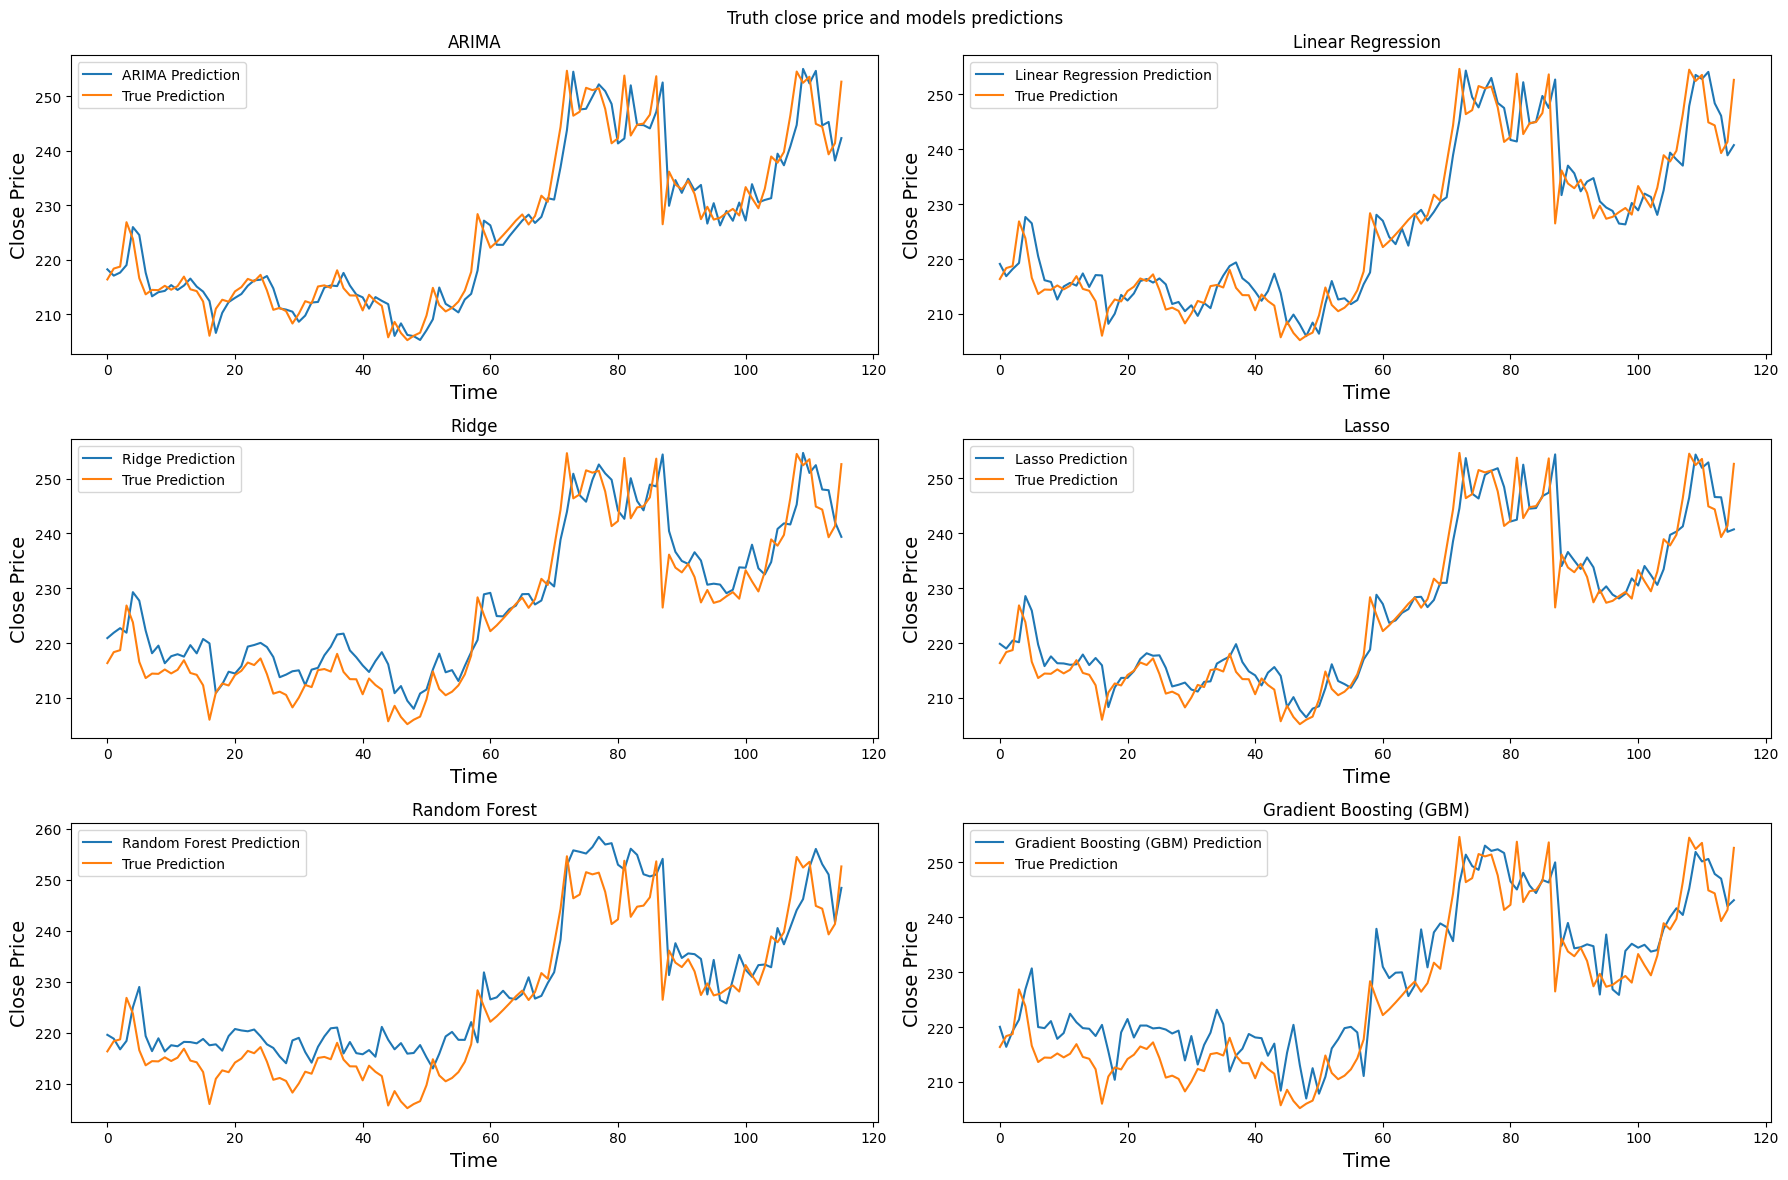

In [ ]:

def visualize_regression_prediction(dataset = 'binance_coin.csv'):
    r"""
    Visualize the comparision between predictions on close prices of the next day on test set of following models:
    - Linear Regression
    - Ridge
    - Lasso
    - Random Forest
    - Gradient Boosting (GBM)
    """
    all_data_split = prepare_datasets([dataset], ALL_FEAT_COLUMN, REGRESSION_LABEL_COLUMN)
    train, val, test = all_data_split[0]
    mape, arima_preds = arima_baseline(train,val,test)
    preds_dict ={}
    preds_dict['ARIMA'] = arima_preds


    models = {
        "Linear Regression":       LinearRegression(),
        "Ridge":                   Ridge(alpha=1.0),
        "Lasso":                   Lasso(alpha=0.1),
        "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting (GBM)": GradientBoostingRegressor(n_estimators=100, random_state=42),
    }

    train_x = np.concatenate([train.x,val.x])
    train_y = np.concatenate([train.y.squeeze(),val.y.squeeze()])
    
    for name, model in models.items():
        model.fit(train_x, train_y)
        preds = model.predict(test.x)
        preds_dict[name] = preds

    fig, axes = plt.subplots(3, 2, figsize=(18, 12))

    for ax, (model_name,preds) in zip(axes.flatten(), preds_dict.items()):
        ax.plot(preds,label=f"{model_name} Prediction")
        ax.plot(test.y, label=f"True Prediction")
        ax.set_title(model_name)
        ax.set_xlabel('Time',fontsize=14)
        ax.set_ylabel('Close Price',fontsize=14)
        ax.legend()

    plt.suptitle('Truth close price and models predictions')
    plt.tight_layout()
    plt.show()


seed_everything(INIT_SEED)
visualize_regression_prediction()
